# Dependencies

In [235]:
%pip install -qq pandas 
%pip install -qq numpy 
%pip install -qq scikit-learn 
%pip install -qq xgboost 
%pip install -qq imblearn 
%pip install -qq tabulate
%pip install -qq xgbimputer
%pip install -qq lightgbm
%pip install -qq catboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [145]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, KFold, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, FunctionTransformer, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, OneSidedSelection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from scipy.stats import randint, uniform
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from xgbimputer import XGBImputer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from tabulate import tabulate
import matplotlib.pyplot as plt
import lightgbm as lgb
import catboost as cb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna


pd.set_option('display.max_columns', 200)


# Load

In [3]:
app_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/application_record.csv")
cred_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/credit_record.csv")

In [4]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
cred_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [6]:
cred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


# Creating Target

In [7]:
is_bad = (
    cred_df['STATUS']
    .isin(['2', '3','4','5'])
    .groupby(cred_df['ID'])
    .max()  # Jika ada minimal 1 True, return 1
    .astype(int)
)

# Aggregrating Credit Records

In [8]:
credit_agg = cred_df.groupby('ID').agg(
    CREDIT_HISTORY_LENGTH=('MONTHS_BALANCE', lambda x: abs(x.min() - x.max()) + 1)).reset_index()
    
# Gabungkan target dengan fitur agregasi kredit
credit_agg['IS_BAD'] = is_bad.values

In [9]:
cred_df['MONTHS_BALANCE'].describe()


count    1.048575e+06
mean    -1.913700e+01
std      1.402350e+01
min     -6.000000e+01
25%     -2.900000e+01
50%     -1.700000e+01
75%     -7.000000e+00
max      0.000000e+00
Name: MONTHS_BALANCE, dtype: float64

In [10]:
credit_agg

,ID,CREDIT_HISTORY_LENGTH,IS_BAD
0,5001711,4,0
1,5001712,19,0
2,5001713,22,0
3,5001714,15,0
4,5001715,60,0
...,...,...,...
45980,5150482,18,0
45981,5150483,18,0
45982,5150484,13,0
45983,5150485,2,0


# Merge Data

In [11]:
new_df = pd.merge(app_df, credit_agg, on="ID", how="inner")

In [12]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,16,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,15,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,1


In [13]:
new_df.isna().sum()

ID                           0
CODE_GENDER                  0
FLAG_OWN_CAR                 0
FLAG_OWN_REALTY              0
CNT_CHILDREN                 0
AMT_INCOME_TOTAL             0
NAME_INCOME_TYPE             0
NAME_EDUCATION_TYPE          0
NAME_FAMILY_STATUS           0
NAME_HOUSING_TYPE            0
DAYS_BIRTH                   0
DAYS_EMPLOYED                0
FLAG_MOBIL                   0
FLAG_WORK_PHONE              0
FLAG_PHONE                   0
FLAG_EMAIL                   0
OCCUPATION_TYPE          11323
CNT_FAM_MEMBERS              0
CREDIT_HISTORY_LENGTH        0
IS_BAD                       0
dtype: int64

In [14]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   AMT_INCOME_TOTAL       36457 non-null  float64
 6   NAME_INCOME_TYPE       36457 non-null  object 
 7   NAME_EDUCATION_TYPE    36457 non-null  object 
 8   NAME_FAMILY_STATUS     36457 non-null  object 
 9   NAME_HOUSING_TYPE      36457 non-null  object 
 10  DAYS_BIRTH             36457 non-null  int64  
 11  DAYS_EMPLOYED          36457 non-null  int64  
 12  FLAG_MOBIL             36457 non-null  int64  
 13  FLAG_WORK_PHONE        36457 non-null  int64  
 14  FLAG_PHONE             36457 non-null  int64  
 15  FL

In [15]:
new_df["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.983103
1    0.016897
Name: proportion, dtype: float64

In [16]:
new_df["IS_BAD"].value_counts()

IS_BAD
0    35841
1      616
Name: count, dtype: int64

In [17]:
for column in new_df.select_dtypes(include='object'):
    unique_values = new_df[column].unique()
    print(f"Unique values in {column}: {unique_values}")

Unique values in CODE_GENDER: ['M' 'F']
Unique values in FLAG_OWN_CAR: ['Y' 'N']
Unique values in FLAG_OWN_REALTY: ['Y' 'N']
Unique values in NAME_INCOME_TYPE: ['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']
Unique values in NAME_EDUCATION_TYPE: ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
Unique values in NAME_FAMILY_STATUS: ['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']
Unique values in NAME_HOUSING_TYPE: ['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
Unique values in OCCUPATION_TYPE: [nan 'Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


# Renaming Feature

In [18]:
new_df = new_df.rename(columns={
    "DAYS_BIRTH" : "AGE",
    "NAME_FAMILY_STATUS" : "MARITAL_STATUS",
    "NAME_HOUSING_TYPE" :  "DWELLING_TYPE",
    "AMT_INCOME_TOTAL" : "ANNUAL_INCOME",
    "OCCUPATION_TYPE" : "JOB_TITLE",
    "NAME_EDUCATION_TYPE" : "EDUCATION_LEVEL",
    "DAYS_EMPLOYED" : "EMPLOYMENT_LENGTH",
    "NAME_INCOME_TYPE" : "EMPLOYMENT_STATUS"})

In [19]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,16,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,15,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,1


In [20]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   ANNUAL_INCOME          36457 non-null  float64
 6   EMPLOYMENT_STATUS      36457 non-null  object 
 7   EDUCATION_LEVEL        36457 non-null  object 
 8   MARITAL_STATUS         36457 non-null  object 
 9   DWELLING_TYPE          36457 non-null  object 
 10  AGE                    36457 non-null  int64  
 11  EMPLOYMENT_LENGTH      36457 non-null  int64  
 12  FLAG_MOBIL             36457 non-null  int64  
 13  FLAG_WORK_PHONE        36457 non-null  int64  
 14  FLAG_PHONE             36457 non-null  int64  
 15  FL

In [21]:
df_retire = new_df[new_df['EMPLOYMENT_STATUS'] == 'Pensioner']
df_retire

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,17,0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,17,0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,17,0
69,5008884,F,N,Y,0,315000.0,Pensioner,Secondary / secondary special,Widow,House / apartment,-20186,365243,1,0,0,0,NaN,1.0,41,0
150,5008974,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22319,365243,1,0,0,0,NaN,2.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36432,5145690,F,N,Y,0,306000.0,Pensioner,Higher education,Married,House / apartment,-21590,365243,1,0,0,0,NaN,2.0,18,1
36434,5145817,F,N,Y,0,90000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22011,365243,1,0,0,0,NaN,2.0,40,1
36439,5148602,M,N,Y,0,225000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22946,365243,1,0,0,0,NaN,2.0,16,1
36441,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-20600,-198,1,0,0,0,Laborers,2.0,21,1


# List of Feature Preprocessing

ID:
* Drop the feature

CODE_GENDER: 
* One hot encoding

AGE from DAYS_BIRTH: 
* Min-max scaling
* Fix skewness
* Abs value and div 365.25

MARITAL_STATUS from NAME_FAMILY_STATUS: 
* One hot encoding

CNT_FAM_MEMBERS:
* Fix outliers

CNT_CHILDERN:
* Fix outliers
* Drop feature

DWELLING_TYPE from NAME_HOUSING_TYPE 
* One hot encoding

ANNUAL_INCOME from AMT_INCOME_TOTAL:
* Remove outliers
* Fix skewness
* Min-max scaling

JOB_TITLE from OCCUPATION_TYPE 
* One hot encoding


EMPLOYMENT_STATUS from NAME_INCOME_TYPE: 
* One hot encoding

EDUCATION_LEVEL from NAME_EDUCATION TYPE: 
* Ordinal encoding

EMPLOYMENT_LENGTH from DAYS_EMPLOYED: 
* Remove outliers
* Min-max scaling
* Abs value and div 365.25
* change days of employments of retirees to 0

FLAG_OWN_CAR: 
* Change it numerical
* One-hot encoding

FLAG_OWN_REALTY: 
* Change it numerical
* One-hot encoding

FLAG_MOBILE: 
* Drop feature (because all of it is 1) 

FLAG_WORK_PHONE : 
* One-hot encoding

FLAG_PHONE: 
* One-hot encoding

FLAG_EMAIL: 
* One-hot encoding

IS_BAD: 
* balance the data with SMOTE

# Preprocessing Data

In [63]:
# Remove Outliers

def remove_outliers(df, features=['CNT_FAM_MEMBERS', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH']):
    if set(features).issubset(df.columns):
        Q1, Q3 = df[features].quantile(0.25), df[features].quantile(0.75)
        IQR = Q3 - Q1
        df = df[~((df[features] < (Q1 - 3 * IQR)) | (df[features] > (Q3 + 3 * IQR))).any(axis=1)]
    return df

In [64]:
# Dropping

def drop_unwanted_features(df, features=['ID', 'FLAG_MOBIL', 'CNT_CHILDREN']):
    return df.drop(columns=[f for f in features if f in df.columns], errors='ignore')

In [65]:
# Convert Time from -(Days) to Age

def convert_time_features(df, features=['EMPLOYMENT_LENGTH', 'AGE']):
    df[features] = df[features].abs() // 365.25
    return df

In [66]:
# Handling Pensioner dengan Employment Status 365243 (masa bekerja tidak valid)

def handle_retirees(df):
    df.loc[df['EMPLOYMENT_LENGTH'] == 365243, 'EMPLOYMENT_LENGTH'] = 0
    return df

In [67]:
# Memperbaiki data skewed dengan merubah value nya dengan cuberoot nya sendiri agar menghasilkan distribusi normal

def adjust_skewness(df, features=['ANNUAL_INCOME', 'AGE', "CREDIT_HISTORY_LENGTH"]):
    df[features] = np.cbrt(df[features])
    return df

In [68]:
# Merubah Y dan N menjadi 1 dan 0

def binarize_features(df, features=['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].map({1: 'Y', 0: 'N'})
    return df

In [69]:
# Melakukan One Hot Encoding ke kolom kategorikal tanpa tingkatan

def apply_one_hot_encoding(df, features=['CODE_GENDER', 'MARITAL_STATUS', 'JOB_TITLE', 'DWELLING_TYPE', 'EMPLOYMENT_STATUS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']):
    encoder = OneHotEncoder()
    encoded_df = pd.DataFrame(encoder.fit_transform(df[features]).toarray(), columns=encoder.get_feature_names_out(features), index=df.index)
    return df.drop(columns=features).join(encoded_df)

In [70]:
# Melakukan ordinal encoding ke kolom kategorikal dengan tingkatan (education level)

def apply_ordinal_encoding(df, features=['EDUCATION_LEVEL']):
    mapping = {'Lower secondary': 0, 
               'Secondary / secondary special': 1, 
               'Incomplete higher': 2,  
               'Higher education': 3, 
               'Academic degree': 4}
    
    for feature in features:
        df[feature] = df[feature].map(mapping)
    
    return df


In [71]:
# scaling numerical featurse dengan min max, karena sudah dibersihkan outliersnya

def scale_features(df, features=['AGE', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH', 'CREDIT_HISTORY_LENGTH']):
    df[features] = StandardScaler().fit_transform(df[features])
    return df

In [72]:
def apply_oversampling(df):
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    X_bal, y_bal = smote.fit_resample(df.drop(columns=['IS_BAD']), df['IS_BAD'])
    return pd.concat([pd.DataFrame(X_bal), pd.DataFrame(y_bal, columns=['IS_BAD'])], axis=1)


In [73]:
def apply_xgb_imputation(df):
    df_copy = df.copy()
    
    # Pisahkan data dengan dan tanpa missing values
    df_train = df_copy[df_copy['JOB_TITLE'].notna()]
    df_missing = df_copy[df_copy['JOB_TITLE'].isna()]
    
    if df_missing.empty:
        return df_copy  # Tidak ada missing value, langsung return
    
    # Encode target variable (JOB_TITLE) menjadi numerik
    JOB_TITLE_mapping = {val: idx for idx, val in enumerate(df_train['JOB_TITLE'].unique())}
    df_train['JOB_TITLE'] = df_train['JOB_TITLE'].map(JOB_TITLE_mapping)
    
    # Fitur dan target
    X_train = df_train.drop(columns=['JOB_TITLE'])
    y_train = df_train['JOB_TITLE']
    X_missing = df_missing.drop(columns=['JOB_TITLE'])
    
    # Model XGBoost
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    model.fit(X_train, y_train)
    
    # Prediksi nilai yang hilang
    y_pred = model.predict(X_missing)
    
    # Mapping kembali ke kategori aslinya
    reverse_mapping = {v: k for k, v in JOB_TITLE_mapping.items()}
    df_copy.loc[df_copy['JOB_TITLE'].isna(), 'JOB_TITLE'] = [reverse_mapping[val] for val in y_pred]
    
    return df_copy

In [74]:
# full preprocessed yang akan nanti kta pakai di akhir

def full_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    df = apply_oversampling(df)
    return df


# ML Algorithm

In [75]:
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "CatBoost": cb.CatBoostClassifier(verbose=0, random_state=42),  # ✅ Paralelisasi otomatis
}


# Baseline Model

In [76]:
def baseline_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [77]:
# Split data
baseline_df = new_df.copy()

baseline_df = baseline_preprocess_data(baseline_df)

X, y = baseline_df.drop(columns=['IS_BAD']), baseline_df['IS_BAD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [78]:
# Define business value scores
TP_value = 200    # Menghindari kredit macet
TN_value = 100    # Mendapatkan keuntungan dari pelanggan baik
FP_value = -100    # Kehilangan calon pelanggan yang layak
FN_value = -500   # Mengalami kredit macet (lebih berbahaya)

In [168]:
def train_result(X_train, X_test, y_train, y_test):
    results = []
    trained_models = {}

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        # Calculate TP, TN, FP, and FN
        tn, fp, fn, tp = cm.ravel()

        # Calculate precision and recall
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1_score = fbeta_score(y_test, y_pred, beta=1)
        f2_score = fbeta_score(y_test, y_pred, beta=2)

        # Calculate business value score
        business_value_score = (tp * TP_value) + (tn * TN_value) + (fp * FP_value) + (fn * FN_value)

        # Format results and append to the list
        results.append([name, precision, recall, f1_score, f2_score, tp, tn, fp, fn, business_value_score])
        
        # Save trained models
        trained_models[name] = clf

    # Create a table using tabulate
    headers = ["Classifier", "Precision", "Recall", "F1 Score", "F2 Score", "TP", "TN", "FP", "FN", "Business Value Score"]
    table = tabulate(results, headers=headers)

    # Print the table
    print(table)
    
    # Return trained models
    return trained_models
     

In [80]:
# Train and evaluate models on train set
trained_models = train_result(X_train, X_test, y_train, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:46:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016693 -> initscore=-4.075949
[LightGBM] [Info] Start training from score -4.075949
Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.522727  0.232323    0.321678    0.261364     23  5796    21    76                  544100
Extra Trees       0.5       0.32323

min max outlier stay
Classifier       Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.35      0.113821    0.171779    0.131579    14  7143    26   109                  660000
Extra Trees       0.375     0.170732    0.234637    0.191606    21  7134    35   102                  663100
XGBoost           0.565217  0.105691    0.178082    0.126214    13  7159    10   110                  662500
LightGBM          0.571429  0.097561    0.166667    0.116959    12  7160     9   111                  662000
CatBoost          0.666667  0.097561    0.170213    0.117647    12  7163     6   111                  662600

standard outlier stay
Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.35      0.113821     0.171779    0.131579    14  7143    26   109                  660000
Extra Trees       0.375     0.170732     0.234637    0.191606    21  7134    35   102                  663100
XGBoost           0.565217  0.105691     0.178082    0.126214    13  7159    10   110                  662500
LightGBM          0.5       0.0569106    0.10219     0.06917      7  7162     7   116                  658900
CatBoost          0.666667  0.097561     0.170213    0.117647    12  7163     6   111                  662600

standard remove outlier (best)
Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.511628  0.222222     0.309859    0.250569    22  5796    21    77                  543400
Extra Trees       0.516129  0.323232     0.397516    0.349345    32  5787    30    67                  548600
XGBoost           0.625     0.151515     0.243902    0.178571    15  5808     9    84                  540900
LightGBM          0.6       0.0909091    0.157895    0.109489     9  5811     6    90                  537300
CatBoost          0.642857  0.0909091    0.159292    0.109756     9  5812     5    90                  537500

minmax remove outlier

Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.511628  0.222222     0.309859    0.250569    22  5796    21    77                  543400
Extra Trees       0.516129  0.323232     0.397516    0.349345    32  5787    30    67                  548600
XGBoost           0.625     0.151515     0.243902    0.178571    15  5808     9    84                  540900
LightGBM          0.555556  0.10101      0.17094     0.120773    10  5809     8    89                  537600
CatBoost          0.642857  0.0909091    0.159292    0.109756     9  5812     5    90                  537500

# Imputation for Job_Title

In [81]:
# Melakukan One Hot Encoding ke kolom kategorikal tanpa tingkatan

def apply_one_hot_encoding_no_job(df, features=['CODE_GENDER', 'MARITAL_STATUS','DWELLING_TYPE', 'EMPLOYMENT_STATUS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']):
    encoder = OneHotEncoder()
    encoded_df = pd.DataFrame(encoder.fit_transform(df[features]).toarray(), columns=encoder.get_feature_names_out(features), index=df.index)
    return df.drop(columns=features).join(encoded_df)

In [82]:
# Melakukan One Hot Encoding ke kolom kategorikal tanpa tingkatan

def apply_one_hot_encoding_job(df, features=["JOB_TITLE"]):
    encoder = OneHotEncoder()
    encoded_df = pd.DataFrame(encoder.fit_transform(df[features]).toarray(), columns=encoder.get_feature_names_out(features), index=df.index)
    return df.drop(columns=features).join(encoded_df)

In [83]:
def imputation_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding_no_job(df)
    df = apply_ordinal_encoding(df)
    df = apply_xgb_imputation(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [84]:

imputation_df = new_df.copy()

imputation_df = imputation_preprocess_data(imputation_df)

# Split data
X, y = imputation_df.drop(columns=['IS_BAD']), imputation_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13504\1451568968.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['JOB_TITLE'] = df_train['JOB_TITLE'].map(JOB_TITLE_mapping)
c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:46:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [85]:
X_train["JOB_TITLE"].isna().sum()

0

In [86]:
X_train = apply_one_hot_encoding_job(X_train)
X_test = apply_one_hot_encoding_job(X_test)

In [87]:
# Train and evaluate models on train set
trained_models = train_result(X_train, X_test, y_train, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:46:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016693 -> initscore=-4.075949
[LightGBM] [Info] Start training from score -4.075949
Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.5       0.222222    0.307692    0.25         22  5795    22    77                  543200
Extra Trees       0.5       0.30303

# Sampling

In [169]:
def sampling_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [170]:

sampling_df = new_df.copy()

sampling_df = sampling_preprocess_data(sampling_df)

# Split data
X, y = sampling_df.drop(columns=['IS_BAD']), sampling_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [167]:
oversampler = RandomOverSampler(random_state=42)
X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

TypeError: train_result() missing 1 required positional argument: 'best_models'

In [91]:
# Apply oversampling only to the training set
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:47:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23268, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11426
[LightGBM] [Info] Number of data points in the train set: 46536, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Classifier       Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.507937  0.323232    0.395062    0.348584    32  5786    31    67                  548400
Extra Trees       0.478873  0.343434    0.4         0.364026    34  5780    37    65     

In [171]:
# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models_adasyn = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [04:05:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23383, number of negative: 23268
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11418
[LightGBM] [Info] Number of data points in the train set: 46651, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501233 -> initscore=0.004930
[LightGBM] [Info] Start training from score 0.004930
Classifier       Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.53125   0.343434    0.417178    0.369565    34  5787    30    65                  550000
Extra Trees       0.5       0.343434    0.407186    0.366379    34  5783    34    65                

In [93]:
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)

train_result(X_train_undersampled, X_test, y_train_undersampled, y_test)    

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:48:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 395
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 251
[LightGBM] [Info] Number of data points in the train set: 790, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
 'CatBoost': <catboost.co

In [94]:
tomek_links = TomekLinks()
X_train_undersampled, y_train_undersampled = tomek_links.fit_resample(X_train, y_train)

train_result(X_train_undersampled, X_test, y_train_undersampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:48:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 23561, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016765 -> initscore=-4.071555
[LightGBM] [Info] Start training from score -4.071555
Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.545455  0.242424    0.335664    0.272727     24  5797    20    75                  545000
Extra Trees       0.457143  0.32323

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
 'CatBoost': <catboost.co

# Feature Selection

In [95]:
def feat_sel_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    # df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [96]:


feature_selection_df = new_df.copy()

# ord
feature_selection_df = feat_sel_preprocess_data(feature_selection_df)

label_encoder = LabelEncoder()
for col in feature_selection_df.select_dtypes(include=['object']).columns:
    feature_selection_df[col] = label_encoder.fit_transform(feature_selection_df[col])

# Split data
X, y = feature_selection_df.drop(columns=['IS_BAD']), feature_selection_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [97]:
feature_selection_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29579 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CODE_GENDER            29579 non-null  int32  
 1   FLAG_OWN_CAR           29579 non-null  int32  
 2   FLAG_OWN_REALTY        29579 non-null  int32  
 3   ANNUAL_INCOME          29579 non-null  float64
 4   EMPLOYMENT_STATUS      29579 non-null  int32  
 5   EDUCATION_LEVEL        29579 non-null  int64  
 6   MARITAL_STATUS         29579 non-null  int32  
 7   DWELLING_TYPE          29579 non-null  int32  
 8   AGE                    29579 non-null  float64
 9   EMPLOYMENT_LENGTH      29579 non-null  float64
 10  FLAG_WORK_PHONE        29579 non-null  int32  
 11  FLAG_PHONE             29579 non-null  int32  
 12  FLAG_EMAIL             29579 non-null  int32  
 13  JOB_TITLE              29579 non-null  int32  
 14  CNT_FAM_MEMBERS        29579 non-null  float64
 15  CREDIT_

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:48:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


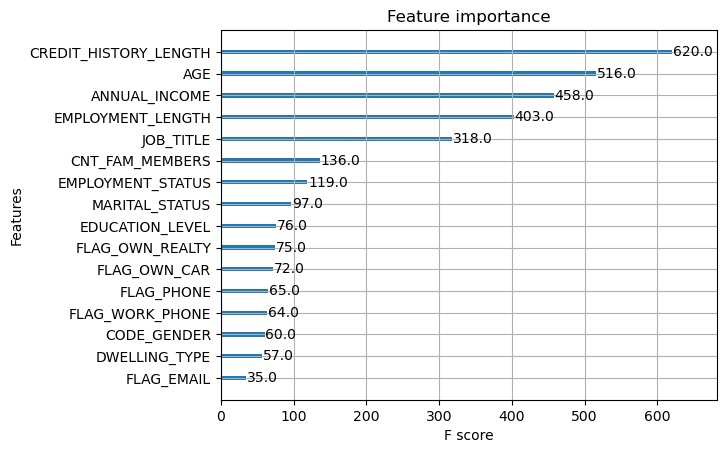

In [98]:
# Train model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)


# Plot feature importance
plot_importance(model)
# Atur ukuran figure
# plt.figure(figsize=(10, 20))  # Lebar 10, tinggi 12
plt.yticks(rotation=0)  # Bisa diganti ke 45 atau 90 jika perlu
plt.show()


In [126]:
selected_features = [
    "AGE",
    "EMPLOYMENT_LENGTH",
    "CREDIT_HISTORY_LENGTH",
    "ANNUAL_INCOME",
    "JOB_TITLE",
    "EMPLOYMENT_STATUS",
    "CNT_FAM_MEMBERS",
    "IS_BAD"
]

selected_feat_df = new_df[selected_features]
selected_feat_df

,AGE,EMPLOYMENT_LENGTH,CREDIT_HISTORY_LENGTH,ANNUAL_INCOME,JOB_TITLE,EMPLOYMENT_STATUS,CNT_FAM_MEMBERS,IS_BAD
0,-12005,-4542,16,427500.0,NaN,Working,2.0,0
1,-12005,-4542,15,427500.0,NaN,Working,2.0,0
2,-21474,-1134,30,112500.0,Security staff,Working,2.0,0
3,-19110,-3051,5,270000.0,Sales staff,Commercial associate,1.0,0
4,-19110,-3051,5,270000.0,Sales staff,Commercial associate,1.0,0
...,...,...,...,...,...,...,...,...
36452,-17348,-2420,12,315000.0,Managers,Working,2.0,1
36453,-12387,-1325,24,157500.0,Medicine staff,Commercial associate,2.0,1
36454,-12387,-1325,33,157500.0,Medicine staff,Pensioner,2.0,1
36455,-17958,-655,10,283500.0,Sales staff,Working,2.0,1


In [127]:
def selected_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    # df = adjust_skewness(df)
    # df = binarize_features(df)
    # df = apply_one_hot_encoding(df)
    # df = apply_ordinal_encoding(df)
    # df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [128]:
selected_feat_df = selected_preprocess_data(selected_feat_df)
selected_feat_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29579 entries, 0 to 36456
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AGE                    29579 non-null  float64
 1   EMPLOYMENT_LENGTH      29579 non-null  float64
 2   CREDIT_HISTORY_LENGTH  29579 non-null  int64  
 3   ANNUAL_INCOME          29579 non-null  float64
 4   JOB_TITLE              24559 non-null  object 
 5   EMPLOYMENT_STATUS      29579 non-null  object 
 6   CNT_FAM_MEMBERS        29579 non-null  float64
 7   IS_BAD                 29579 non-null  int32  
dtypes: float64(4), int32(1), int64(1), object(2)
memory usage: 1.9+ MB


In [129]:
# Inisialisasi scaler
scaler = StandardScaler()
numerical_cols = ["AGE", "EMPLOYMENT_LENGTH", "CREDIT_HISTORY_LENGTH", "ANNUAL_INCOME", "CNT_FAM_MEMBERS"]

# Transformasi numerik dengan cbrt dan standard scaling
for col in numerical_cols:
    selected_feat_df[col] = np.cbrt(selected_feat_df[col])  
    selected_feat_df[col] = scaler.fit_transform(selected_feat_df[[col]])  # Gunakan double bracket

# One-Hot Encoding untuk kolom kategorikal
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_cols = ["JOB_TITLE", "EMPLOYMENT_STATUS"]

for col in categorical_cols:
    encoded = ohe.fit_transform(selected_feat_df[[col]])  # Pastikan input dalam bentuk 2D
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out([col]))  
    selected_feat_df = selected_feat_df.drop(columns=[col]).reset_index(drop=True)
    selected_feat_df = pd.concat([selected_feat_df, encoded_df], axis=1)

selected_feat_df

,AGE,EMPLOYMENT_LENGTH,CREDIT_HISTORY_LENGTH,ANNUAL_INCOME,CNT_FAM_MEMBERS,IS_BAD,JOB_TITLE_Accountants,JOB_TITLE_Cleaning staff,JOB_TITLE_Cooking staff,JOB_TITLE_Core staff,JOB_TITLE_Drivers,JOB_TITLE_HR staff,JOB_TITLE_High skill tech staff,JOB_TITLE_IT staff,JOB_TITLE_Laborers,JOB_TITLE_Low-skill Laborers,JOB_TITLE_Managers,JOB_TITLE_Medicine staff,JOB_TITLE_Private service staff,JOB_TITLE_Realty agents,JOB_TITLE_Sales staff,JOB_TITLE_Secretaries,JOB_TITLE_Security staff,JOB_TITLE_Waiters/barmen staff,JOB_TITLE_nan,EMPLOYMENT_STATUS_Commercial associate,EMPLOYMENT_STATUS_Pensioner,EMPLOYMENT_STATUS_State servant,EMPLOYMENT_STATUS_Student,EMPLOYMENT_STATUS_Working
0,-0.799001,0.947014,-0.127712,2.362154,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.799001,0.947014,-0.205634,2.362154,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.748574,-0.273543,0.725735,-0.944988,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.242168,0.530025,-1.304405,1.054470,-1.663884,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.242168,0.530025,-1.304405,1.054470,-1.663884,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29574,0.789491,0.266545,-0.462491,1.471004,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
29575,-0.679204,-0.273543,0.402115,-0.244671,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
29576,-0.679204,-0.273543,0.871468,-0.244671,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
29577,0.974242,-0.910705,-0.658630,1.183999,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Split data
X, y = selected_feat_df.drop(columns=['IS_BAD']), selected_feat_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:04:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23268
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016693 -> initscore=-4.075949
[LightGBM] [Info] Start training from score -4.075949
Classifier       Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.484848  0.161616    0.242424    0.18648      16  5800    17    83                  540000
Extra Trees       0.510638  0.242424    0.328767    0.27088      24  5794    23    75              

In [131]:
# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:03:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23383, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5786
[LightGBM] [Info] Number of data points in the train set: 46651, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501233 -> initscore=0.004930
[LightGBM] [Info] Start training from score 0.004930
Classifier       Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.491525  0.292929    0.367089    0.318681    29  5787    30    70                  546500
Extra Trees       0.454545  0.30303  

# Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning dictionary
param_distributions = {
    "Random Forest": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(10, 50),
        "max_features": ["sqrt", "log2"],
        "min_samples_split": randint(2, 10)
    },
    "Extra Trees": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(10, 50),
        "max_features": ["sqrt", "log2"],
        "min_samples_split": randint(2, 10)
    },
    "XGBoost": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": randint(3, 10),
        "subsample": uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5)
    },
    "LightGBM": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "num_leaves": randint(20, 150),
        "max_depth": randint(3, 10),
        "subsample": uniform(0.5, 0.5)
    },
    "CatBoost": {
        "iterations": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "depth": randint(3, 10)
    }
}

# Hyperparameter tuning function
def tune_hyperparameters(X_train, y_train):
    best_models = {}
    for name, param_grid in param_distributions.items():
        print(f"Tuning hyperparameters for {name}...")
        
        model = {
            "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
            "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1),
            "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
            "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
        }[name]
        
        random_search = RandomizedSearchCV(
            model, param_distributions=param_grid, 
            n_iter=10, cv=3, scoring="f1", n_jobs=-1, verbose=1, random_state=42
        )
        random_search.fit(X_train, y_train)
        best_models[name] = random_search.best_estimator_

        print(f"Best parameters for {name}: {random_search.best_params_}\n")

    return best_models

# Model training and evaluation
def train_result(X_train, X_test, y_train, y_test, models, TP_value=TP_value, TN_value=TN_value, FP_value=FP_value, FN_value=FN_value):
    results = []
    trained_models = {}
    
    for name, clf in models.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1_score = fbeta_score(y_test, y_pred, beta=1)
        f2_score = fbeta_score(y_test, y_pred, beta=2)
        business_value_score = (tp * TP_value) + (tn * TN_value) + (fp * FP_value) + (fn * FN_value)
        
        results.append([name, precision, recall, f1_score, f2_score, tp, tn, fp, fn, business_value_score])
        trained_models[name] = clf
    
    headers = ["Classifier", "Precision", "Recall", "F1 Score", "F2 Score", "TP", "TN", "FP", "FN", "Business Value Score"]
    print(tabulate(results, headers=headers))
    
    return trained_models


In [142]:
def hyp_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [143]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Hyperparameter tuning harus dilakukan pada dataset yang sudah di-oversample
best_models = tune_hyperparameters(X_train_oversampled, y_train_oversampled)

# Train dan evaluasi juga menggunakan dataset yang sudah di-oversample
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test, best_models)

Tuning hyperparameters for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Random Forest: {'max_depth': 42, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 71}

Tuning hyperparameters for Extra Trees...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Extra Trees: {'max_depth': 31, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 137}

Tuning hyperparameters for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:19:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters for XGBoost: {'colsample_bytree': 0.6872700594236812, 'learning_rate': 0.2952142919229748, 'max_depth': 5, 'n_estimators': 121, 'subsample': 0.7993292420985183}

Tuning hyperparameters for LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23383, number of negative: 23268
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11418
[LightGBM] [Info] Number of data points in the train set: 46651, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501233 -> initscore=0.004930
[LightGBM] [Info] Start training from score 0.004930
Best parameters for LightGBM: {'learning_rate': 0.2597327922401265, 'max_depth': 8, 'n_estimators': 179, 'num_leaves': 40, 'subsample': 0.80874075481

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:21:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23383, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11418
[LightGBM] [Info] Number of data points in the train set: 46651, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501233 -> initscore=0.004930
[LightGBM] [Info] Start training from score 0.004930
Classifier       Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest     0.584906  0.313131    0.407895    0.345212    31  5795    22    68                  549500
Extra Trees       0.448718  0.353535

In [144]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

best_models = tune_hyperparameters(X_train, y_train)
trained_models = train_result(X_train, X_test, y_train, y_test, best_models)

Tuning hyperparameters for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Random Forest: {'max_depth': 31, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 137}

Tuning hyperparameters for Extra Trees...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Extra Trees: {'max_depth': 42, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 71}

Tuning hyperparameters for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:35:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters for XGBoost: {'colsample_bytree': 0.6872700594236812, 'learning_rate': 0.2952142919229748, 'max_depth': 5, 'n_estimators': 121, 'subsample': 0.7993292420985183}

Tuning hyperparameters for LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016693 -> initscore=-4.075949
[LightGBM] [Info] Start training from score -4.075949
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:36:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016693 -> initscore=-4.075949
[LightGBM] [Info] Start training from score -4.075949
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Classifier       Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-------------  -----------  ---

In [158]:
def objective(trial, X_train, y_train, model_name):
    """Fungsi untuk Optuna dalam mencari hyperparameter terbaik per model."""
    
    model_params = {
        "Random Forest": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 5, 50),
            "max_features": trial.suggest_categorical("max_features", ["auto", "sqrt", "log2"])
        },
        "Extra Trees": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 5, 50),
            "max_features": trial.suggest_categorical("max_features", ["auto", "sqrt", "log2"])
        },
        "XGBoost": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 10)
        },
        "LightGBM": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150)
        },
        "CatBoost": {
            "iterations": trial.suggest_int("iterations", 50, 200),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "depth": trial.suggest_int("depth", 3, 10)
        }
    }

    model = {
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1, **model_params["Random Forest"]),
        "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1, **model_params["Extra Trees"]),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1, **model_params["XGBoost"]),
        "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, **model_params["LightGBM"]),
        "CatBoost": CatBoostClassifier(verbose=0, random_state=42, **model_params["CatBoost"])
    }[model_name]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    return accuracy_score(y_train, y_pred)

def tune_hyperparameters(X_train, y_train):
    best_models = {}

    model_names = ["Random Forest", "Extra Trees", "XGBoost", "LightGBM", "CatBoost"]

    for name in model_names:
        print(f"Tuning {name}...")
        study = optuna.create_study(direction="maximize")
        study.optimize(lambda trial: objective(trial, X_train, y_train, name), n_trials=20)

        best_params = study.best_params
        print(f"Best parameters for {name}: {best_params}\n")

        if name == "Random Forest":
            best_models[name] = RandomForestClassifier(
                random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                max_features=best_params["max_features"]
            )
        elif name == "Extra Trees":
            best_models[name] = ExtraTreesClassifier(
                random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                max_features=best_params["max_features"]
            )
        elif name == "XGBoost":
            best_models[name] = XGBClassifier(
                use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                learning_rate=best_params["learning_rate"],
                max_depth=best_params["max_depth"]
            )
        elif name == "LightGBM":
            best_models[name] = LGBMClassifier(
                random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                learning_rate=best_params["learning_rate"],
                num_leaves=best_params["num_leaves"]
            )
        elif name == "CatBoost":
            best_models[name] = CatBoostClassifier(
                verbose=0, random_state=42,
                iterations=best_params["iterations"],
                learning_rate=best_params["learning_rate"],
                depth=best_params["depth"]
            )

    return best_models


def fbeta_score(y_true, y_pred, beta=2):
    """Menghitung F2 Score secara manual."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    if precision + recall == 0:
        return 0
    return (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

def calculate_business_value(tp, tn, fp, fn):
    """Contoh perhitungan Business Value Score (bisa disesuaikan dengan kebutuhan bisnis)."""
    return tp * TP_value + tn * TN_value + fp * FP_value + fn * FN_value

def train_result(X_train, X_test, y_train, y_test, best_models):
    results = []

    for name, model in best_models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Menghitung metrik evaluasi
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f2 = fbeta_score(y_test, y_pred, beta=2)

        # Menghitung confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        # Menghitung business value score
        business_value = calculate_business_value(tp, tn, fp, fn)

        results.append([name, precision, recall, f1, f2, tp, tn, fp, fn, business_value])

    # Membuat DataFrame untuk tampilan tabel
    df_results = pd.DataFrame(results, columns=[
        "Classifier", "Precision", "Recall", "F1 Score", "F2 Score", 
        "TP", "TN", "FP", "FN", "Business Value Score"
    ])

    # Menampilkan tabel dengan format rapi
    print(df_results.to_string(index=False))
    
    return df_results



In [160]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Hyperparameter tuning harus dilakukan pada dataset yang sudah di-oversample
best_models = tune_hyperparameters(X_train_oversampled, y_train_oversampled)

# Train dan evaluasi juga menggunakan dataset yang sudah di-oversample
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test, best_models)

[I 2025-03-08 03:16:25,422] A new study created in memory with name: no-name-e42a47a6-005c-4c39-879f-d1f0f585e7c6


Tuning Random Forest...


c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-08 03:16:28,788] Trial 0 finished with value: 0.9993569269683393 and parameters: {'n_estimators': 162, 'max_depth': 50, 'max_features': 'sqrt', 'learning_rate': 0.04386390182238078, 'num_leaves': 118, 'iterations': 193, 'depth': 4}. Best is trial 0 with value: 0.9993569269683393.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call t

Best parameters for Random Forest: {'n_estimators': 162, 'max_depth': 50, 'max_features': 'sqrt', 'learning_rate': 0.04386390182238078, 'num_leaves': 118, 'iterations': 193, 'depth': 4}

Tuning Extra Trees...


[I 2025-03-08 03:17:31,888] Trial 0 finished with value: 0.9992926196651734 and parameters: {'n_estimators': 196, 'max_depth': 46, 'max_features': 'sqrt', 'learning_rate': 0.2820237567507331, 'num_leaves': 130, 'iterations': 158, 'depth': 8}. Best is trial 0 with value: 0.9992926196651734.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_feat

...

Best parameters for CatBoost: {'n_estimators': 200, 'max_depth': 9, 'max_features': 'sqrt', 'learning_rate': 0.2975616729512472, 'num_leaves': 147, 'iterations': 199, 'depth': 10}

Training Random Forest...
Training Extra Trees...


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Training XGBoost...


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:25:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23383, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11418
[LightGBM] [Info] Number of data points in the train set: 46651, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501233 -> initscore=0.004930
[LightGBM] [Info] Start training from score 0.004930
Training CatBoost...
   Classifier  Precision   Recall  F1 Score  F2 Score  TP   TN  FP  FN  Business Value Score
Random Forest   0.531250 0.343434  0.417178  0.369565  34 5787  30  65                550000
  Extra Trees   0.486111 0.353535  0.409357  0.373932  35 5780  37  64                549300
      XGBoost   0.530303 0.353535  0.42424

In [161]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

best_models = tune_hyperparameters(X_train, y_train)
trained_models = train_result(X_train, X_test, y_train, y_test, best_models)

[I 2025-03-08 03:25:40,767] A new study created in memory with name: no-name-9927053a-090e-41b7-9f52-db7908222bce
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(


Tuning Random Forest...


[I 2025-03-08 03:25:41,699] Trial 0 finished with value: 0.9836453535054727 and parameters: {'n_estimators': 133, 'max_depth': 7, 'max_features': 'log2', 'learning_rate': 0.06228609333898193, 'num_leaves': 83, 'iterations': 166, 'depth': 3}. Best is trial 0 with value: 0.9836453535054727.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_featu

Best parameters for Random Forest: {'n_estimators': 189, 'max_depth': 47, 'max_features': 'log2', 'learning_rate': 0.21773537165846654, 'num_leaves': 108, 'iterations': 145, 'depth': 4}

Tuning Extra Trees...


[I 2025-03-08 03:26:09,366] Trial 0 finished with value: 0.9856315767231543 and parameters: {'n_estimators': 97, 'max_depth': 13, 'max_features': 'auto', 'learning_rate': 0.27491268921038275, 'num_leaves': 118, 'iterations': 198, 'depth': 4}. Best is trial 0 with value: 0.9856315767231543.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-08 03:26:09,997] Trial 1 finished with value: 0.9860541774077674 and parameters: {'n_estimators': 68, 'max_depth': 14, 'max_features': 'sqrt', 'learning_rate': 0.09967378913377918, 'num_leaves': 54, 'iterations

...

Best parameters for LightGBM: {'n_estimators': 193, 'max_depth': 44, 'max_features': 'log2', 'learning_rate': 0.10936668135088037, 'num_leaves': 137, 'iterations': 188, 'depth': 5}

Tuning CatBoost...


[I 2025-03-08 03:27:04,300] Trial 0 finished with value: 0.9838566538477792 and parameters: {'n_estimators': 168, 'max_depth': 28, 'max_features': 'sqrt', 'learning_rate': 0.03695734837390024, 'num_leaves': 32, 'iterations': 156, 'depth': 3}. Best is trial 0 with value: 0.9838566538477792.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-08 03:27:05,962] Trial 1 finished with value: 0.9838989139162405 and parameters: {'n_estimators': 158, 'max_depth': 18, 'max_features': 'auto', 'learning_rate': 0.09478042519836198, 'num_leaves': 86, 'iteration

Best parameters for CatBoost: {'n_estimators': 53, 'max_depth': 25, 'max_features': 'log2', 'learning_rate': 0.270292898466244, 'num_leaves': 102, 'iterations': 172, 'depth': 9}

Training Random Forest...
Training Extra Trees...
Training XGBoost...


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:28:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 395, number of negative: 23268
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016693 -> initscore=-4.075949
[LightGBM] [Info] Start training from score -4.075949
Training CatBoost...
   Classifier  Precision   Recall  F1 Score  F2 Score  TP   TN  FP  FN  Business Value Score
Random Forest   0.479167 0.232323  0.312925  0.259009  23 5792  25  76                543300
  Extra Trees   0.500000 0.313131  0.385093  0.338428  31 5786  31  68                547700
      XGBoost   0.545455 0.242424  0.335664 

In [163]:
best_models

{'Random Forest': RandomForestClassifier(max_depth=47, max_features='log2', n_estimators=189,
                        n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(max_depth=34, max_features='log2', n_estimators=182,
                      n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2863083113943273, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=49, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=N

In [172]:
trained_models_adasyn

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
 'CatBoost': <catboost.co

# Save Model

In [ ]:
import pickle

# Simpan model XGBoost
with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(best_models['XGBoost'], file)

# Simpan model LightGBM
with open('lightgbm_model.pkl', 'wb') as file:
    pickle.dump(best_models['LightGBM'], file)



In [173]:
# Simpan model Random Forest
with open('random_forest.pkl', 'wb') as file:
    pickle.dump(trained_models_adasyn['Random Forest'], file)